# ($\epsilon, \, \delta$) - Differential Privacy simulation

## Overview:
We will be demonstrating the core concepts of differential privacy simulation, and how exactly DP works. For this we put down the basic theoretical concepts, build up the concept of privacy leakage in a non-binary manner and implement the formal definition of the $(\epsilon, \, \delta)$ using a synthetic database. 

## Theory:
1. Suppose a database $\chi \in \mathbb{R}^{n_0}$ where $n_0$ is the number of categories that our database distributed that data in. Then, $\chi$ is functionally a histogram-type row vector, with each index indicating a single class of data and the value of the entry for that index in the database being the frequency of occurence of that data. We assume the database to be based off of a single particular schema/feature, and classify our data within subclasses of that feature.
2. Now, suppose an external party that tries to analyze that data. We define the concept of privacy such that- "The amount of information the analyst had regarding any specific individual before analyzing the data and drawing interpretation should be approximately equivalent to the information she had post-analysis." She may be able to draw conclusions regarding a collection of individuals after the process, but she should not have too much information about any one specific individual. In the case she does gain such information, privacy of the respective individual is compromised.
3. Revealing the sensitivity of database with respect to a specific individual can be done by multiple types of attacks- Linkage attacks (relating two different datasets together), Differencing attacks, etc. A very basic solution to this is adding noise to the values in the database using a specifically designed mechanism $\mathcal{M}$.
4. A mechanism $\mathcal{M}$ is a probabilistic process used to add random noise to the values in the database in such a way, that we don't lose much information and are able to protect the privacy of each specific individual. Some popular mechanisms used to add noise to databases are Laplacian and Gaussian mechanisms, which is what we will use to simulate the main task.

## Formal definitions:
1. Suppose $\chi = (x^{(1)}, \, x^{(2)}, \, x^{(3)}, \, ... x^{(n_0)})$ is a given database vector with $n_0$ classes. Then, a mechanism $\mathcal{M}: \mathbb{R}^{n_0} \longrightarrow \mathbb{R}^{n_0}$ is a function that transforms $\chi$ into a random database $\chi' = (x'^{(1)}, \, x'^{(2)}, \, x'^{(3)}, ... x'^{(n_0)})$ where the $i^{th}$ entry $x'^{(i)} \sim D(x^{(1)}, \sigma)$  where D is a probability distribution depending on the mechanism $\mathcal{M}$ so chosen. We have: $\mathcal{M}(\chi) = \chi'$.
2. We define the concept of neighbouring databases that are based on the same schema, have the same number of subclasses, but differ in exactly 1 sample numerically speaking. If $\chi$ and $\mathcal{Y}$ are two databases $\in \mathbb{R}^{n_0}$, then the $l_1$ norm of a database vector is denoted by $||\chi||_1 = \sum_{i = 1}^{n_0} |x^{(i)}|$. Two neighbouring databases are defined such that $||\chi - \mathcal{Y}||_1 \leq 1$. We use these definitions to define the concept of a differentially private mechanism with respect to two parameters that we introduce in the following point.
3. A mechanism $\mathcal{M}$ is said to be $(\epsilon, \, \delta) - $ differentially private if two neighbouring databases $\chi$ and $\mathcal{Y}$ satisfy the following inequality: $$Pr[\mathcal{M} (\chi) = \mathbb{E}] \leq e^{\epsilon} Pr[\mathcal{M} (\mathcal{Y}) = \mathbb{E}] + \delta $$ symmetrically.

## Key points:
1. In this, we have two special cases. If $\delta = 0$, then we have a pure $(\epsilon, \, 0) - $ differentially private mechanism for a database, which implies a perfect DP such that the $Pr[\mathcal{M} (\chi) = \mathbb{E}] = X$ and $Pr[\mathcal{M} (\mathcal{Y}) = \mathbb{E}] = Y$ will be comparable and may differ only by a factor of $e^{\epsilon}$. This means that the probability of the likelihood ratio $\frac{X}{Y}$ blowing up at any event database $\mathcal{E}$ is absolutely 0, since X and Y remain bounded with respect to each other.
2. In the practical sense, it means that the noise introduced by the mechanism will not cause the likelihood ratio, which in other words is an indicator of privacy loss, to blow up at any specific $\mathbb{E}$ for two neighbouring databases, which will differ by exactly 1 individual. If the likelihood ratio blows up, then it means that the output to some query for the database formed by an external party may be able to reveal some integral and unique information regarding that specific individual that was removed from the original database to create our supposed neighbour. This is a privacy leak, and a $(\epsilon, \, 0) - $ differentially private mechanism nullifies that.
3. On the other hand, even if we use an abysmally small $\delta > 0$, this particular likelihood ratio then gaurantees that there MIGHT be a "bad selection" of $\mathbb{E}$ under this mechanism that can cause the likelihood ratio to blow up for some specific "$\delta$ - region" in our supposed noise distribution. This means at that particular selection, the privacy may be compromised. We will be simulating this exact difference, and show the boundedness of the two different DP types.

## Simulation outline:
1. We will be using $\mathcal{L}-$ mechanism and $\mathcal{G}-$ mechanism as $(\epsilon, \, 0)$ - DP and $(\epsilon, \, \delta)$ - DP mechanisms each on a simulated database $\chi$.
2. We will pass out 2 specific outputs for the queries simultaneously, with the database having 3 particular categories, each with $x_1, \, x_2, \, x_3$ samples per category respectively.
3. Let's say $f(\chi) = (x_1 + x_2 + x_3, \, x_1 + x_3) \in \mathbb{R}^2$ is the output/query function. A perfect no-noise non-private algorithm will give this exact output. Let's call the 2 output components as $f(\chi)_1$ and $f(\chi)_2$.
4. We define the sensitivity $\Delta f = \max\limits_{\chi, \, \mathcal{Y}} ||f(\chi) - f(\mathcal{Y})||_1$ where $||\chi - \mathcal{Y}||_1 = 1$. In other words, what is the maximum possible perturbation that we might get in our output if we remove any 1 particular individual is the sensitivity.
5. For our case, clearly, $\Delta f$ will have the correct value when when both the output are changed/perturbed by exactly 1 sample, that is, $f(\chi)_1 = f(\mathcal{Y})_1 + 1$ (1 sample not included in counting), $f(\chi)_1 = f(\mathcal{Y})_1 + 1$ (same sample not included). This means $\Delta f = \max\limits_{\chi, \, \mathcal{Y}} ||f(\chi) - f(\mathcal{Y})||_1 = \sqrt{1 + 1} = \sqrt{2}$.
6. Using the Gaussian and Laplacian mechanisms, we simulate the process for various 1000 epsilons, keeping $\delta$ fixed $(\delta = \frac{1}{9})$; this is a statistically preferred value. However, we will also show how the accuracy given by both mechanisms changes with changing $\delta$ for a closed form expression we have derived. For each epsilon, we also show how the changing epsilon affects the outputs for the Laplace and Gaussian mechanisms.
7. We observe that for increasing $\epsilon$, and choosing an arbitrary confidence interval of $c = 0.95$, the interval widths decrease in a pattern inversely proportional to $\epsilon$, the exact closed formula being $$\frac{W_G}{2} = 2 \frac{\Delta f}{\epsilon} erf^{-1}(c) \sqrt{ln(\frac{1.25}{\delta})}$$ for the Gaussian case, and $$\frac{W_{L}}{2} = \frac{\Delta f}{\epsilon} ln(\frac{1}{1 - c})$$ for the Laplacian case.
8. We observe that by sketching the surface for the ratio $$\frac{W_G}{W_L} = \frac{2 erf^{-1} \sqrt{ln(\frac{1.25}{\delta})}}{ln(\frac{1}{1 - c})}$$ with respect to c and $\delta$, we can obtain an exact boundary at which for the same $\epsilon$ and confidence interval, we can tell which mechanism is more accurate to the true output.

In [1]:
#Import the main libraries.
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
#Define the number of 3 category samples via user input.
x1 = int(input("Enter no. of samples in category 1: "))
x2 = int(input("Enter no. of samples in category 2: "))
x3 = int(input("Enter no. of samples in category 3: "))
X = np.array([x1, x2, x3])
X = X.reshape(-1, 1)

Enter no. of samples in category 1:  33
Enter no. of samples in category 2:  33
Enter no. of samples in category 3:  34


In [3]:
#Generating random seed for reproducibility purposes.
np.random.seed(90)

#We define the Laplacian mechanism to generate a noise 2D vector that we will add to our true output for simulation of privacy.
def Laplace_noise(eps):
    L_noise = np.random.laplace(0, (2 ** 0.5) / eps, size = (2, 1))
    return L_noise

#We define the Gaussian mechanism to generate a noise 2D vector that we will add to our true output for simulation of our privacy.
def Gaussian_noise(eps, delta):
    N_noise = np.random.normal(0, (2 * (np.log(1.25 / delta) ** 0.5)) / eps, size = (2, 1))
    return N_noise

In [4]:
#We put 100 equally spaced epsilons in a numpy array for the range 0 to 20.
epsilons = np.linspace(0, 20, 101)[1:]
#Defining the delta value.
delta = 1 / 9
#We want to store out first and second outputs for both gaussian and laplace mechanisms. We do so in separate arrays.
gauss_results_1 = []
gauss_results_2 = []
lap_results_1 = []
lap_results_2 = []
#Iterator for while loop.
it = 0
#Defining the output vector.
true_op = np.array([x1 + x2 + x3, x1 + x3])
true_op = true_op.reshape(-1, 1)
#Running the simulation and generating random values for each epsilon. We append those values to our arrays.
while(it < 100):
    epsilon = epsilons[it]
    op_lap = true_op + Laplace_noise(epsilon)
    op_gauss = true_op + Gaussian_noise(epsilon, delta)
    gauss_results_1.append(op_gauss[0, 0])
    gauss_results_2.append(op_gauss[1, 0])
    lap_results_1.append(op_lap[0, 0])
    lap_results_2.append(op_lap[1, 0])
    it += 1

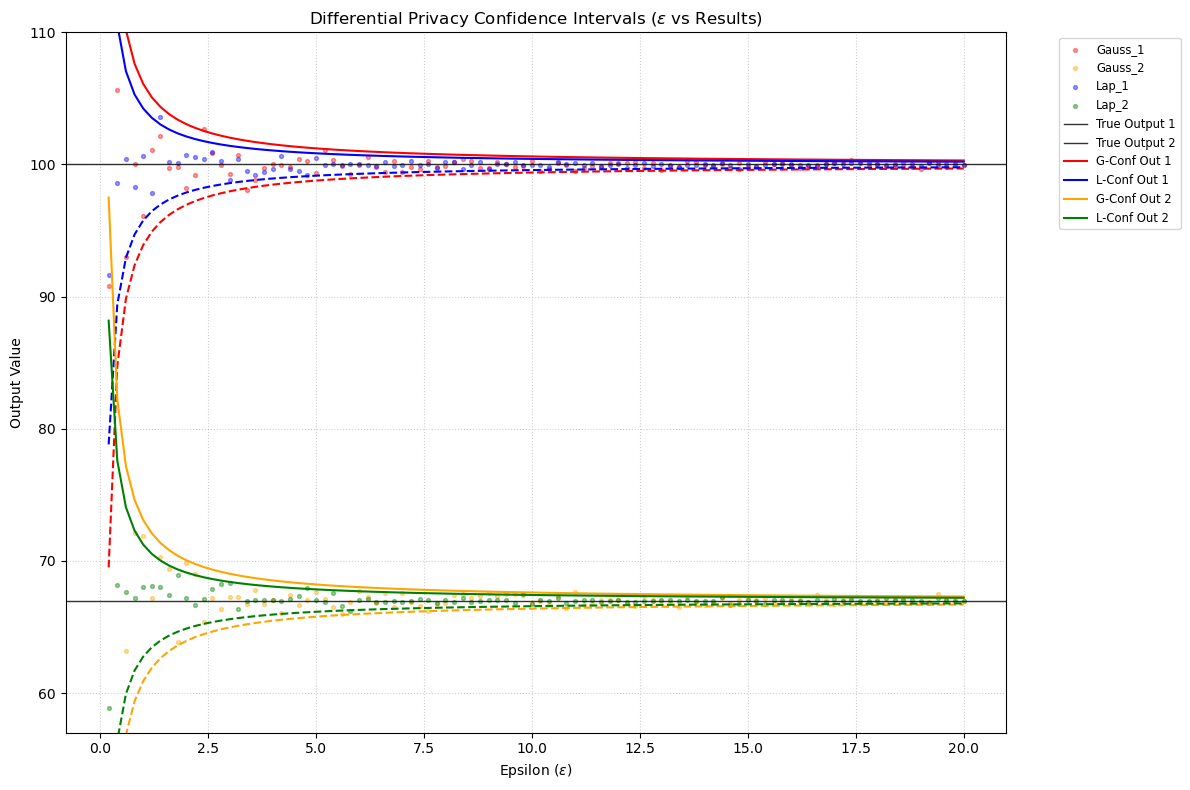

In [5]:
#We get the scatter plot for the 2 outputs for both gaussian and laplace cases.
#A rough trend to be noted in both is that the dots start to center around the dotted y = true output lines as epsilon increases.
#Red dots represent Gaussian mechanism yield 1st output.
#Orange dots represent Gaussian mechanism yield 2nd output.
#Blue dots represent Laplacian mechanism yield 1st output.
#Green dots represent Laplacian mechanism yield 2nd output.
#We also try to represent the gaussian confidence bounds with red and orange for the 2 outputs respectively. The graph is hyperbolic wrt epsilon.
#We also try to represent the laplacian confidence bounds with blue and green for the 2 outputs respectively. The graph is hyperbolic wrt epsilon.
#Used gemini to produce the graphs accordingly.
from scipy.special import erfinv

delta_f = np.sqrt(2)
delta_val = 1/9
base1 = x1 + x2 + x3
base2 = x1 + x3

# --- Confidence Interval Calculations ---
# G-confidence term
g_term = 2 * (delta_f / epsilons) * erfinv(0.95) * np.sqrt(np.log(1.25 / delta_val))

# L-confidence term
l_term = (delta_f / epsilons) * np.log(1 / 0.05)

# --- Plotting ---
plt.figure(figsize=(12, 8))

# 1. Scatter Plots (Original Data)
plt.scatter(epsilons, gauss_results_1, color='red',    label='Gauss_1', s=8, alpha=0.4)
plt.scatter(epsilons, gauss_results_2, color='orange', label='Gauss_2', s=8, alpha=0.4)
plt.scatter(epsilons, lap_results_1,   color='blue',   label='Lap_1',   s=8, alpha=0.4)
plt.scatter(epsilons, lap_results_2,   color='green',  label='Lap_2',   s=8, alpha=0.4)

# 2. Horizontal "True Output" Lines
plt.axhline(y=base1, color='black', linestyle='-', linewidth=1, alpha=0.8, label='True Output 1')
plt.axhline(y=base2, color='black', linestyle='-', linewidth=1, alpha=0.8, label='True Output 2')

# 3. Confidence Curves for Output 1 (base1)
# Gaussian Confidence (Red)
plt.plot(epsilons, base1 + g_term, color='red', lw=1.5, label='G-Conf Out 1')
plt.plot(epsilons, base1 - g_term, color='red', lw=1.5, linestyle='--') # Mirrored

# Laplacian Confidence (Blue)
plt.plot(epsilons, base1 + l_term, color='blue', lw=1.5, label='L-Conf Out 1')
plt.plot(epsilons, base1 - l_term, color='blue', lw=1.5, linestyle='--') # Mirrored

# 4. Confidence Curves for Output 2 (base2)
# Gaussian Confidence (Orange)
plt.plot(epsilons, base2 + g_term, color='orange', lw=1.5, label='G-Conf Out 2')
plt.plot(epsilons, base2 - g_term, color='orange', lw=1.5, linestyle='--') # Mirrored

# Laplacian Confidence (Green)
plt.plot(epsilons, base2 + l_term, color='green', lw=1.5, label='L-Conf Out 2')
plt.plot(epsilons, base2 - l_term, color='green', lw=1.5, linestyle='--') # Mirrored

# --- Styling ---
plt.title(fr"Differential Privacy Confidence Intervals ($\epsilon$ vs Results)")
plt.xlabel(fr"Epsilon ($\epsilon$)")
plt.ylabel("Output Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle=':', alpha=0.6)

# Set y-limit to focus on the area around the true outputs
# Since 1/eps blows up at zero, we clip the view
plt.ylim(min(base1, base2) - 10, max(base1, base2) + 10) 

plt.tight_layout()
plt.show()

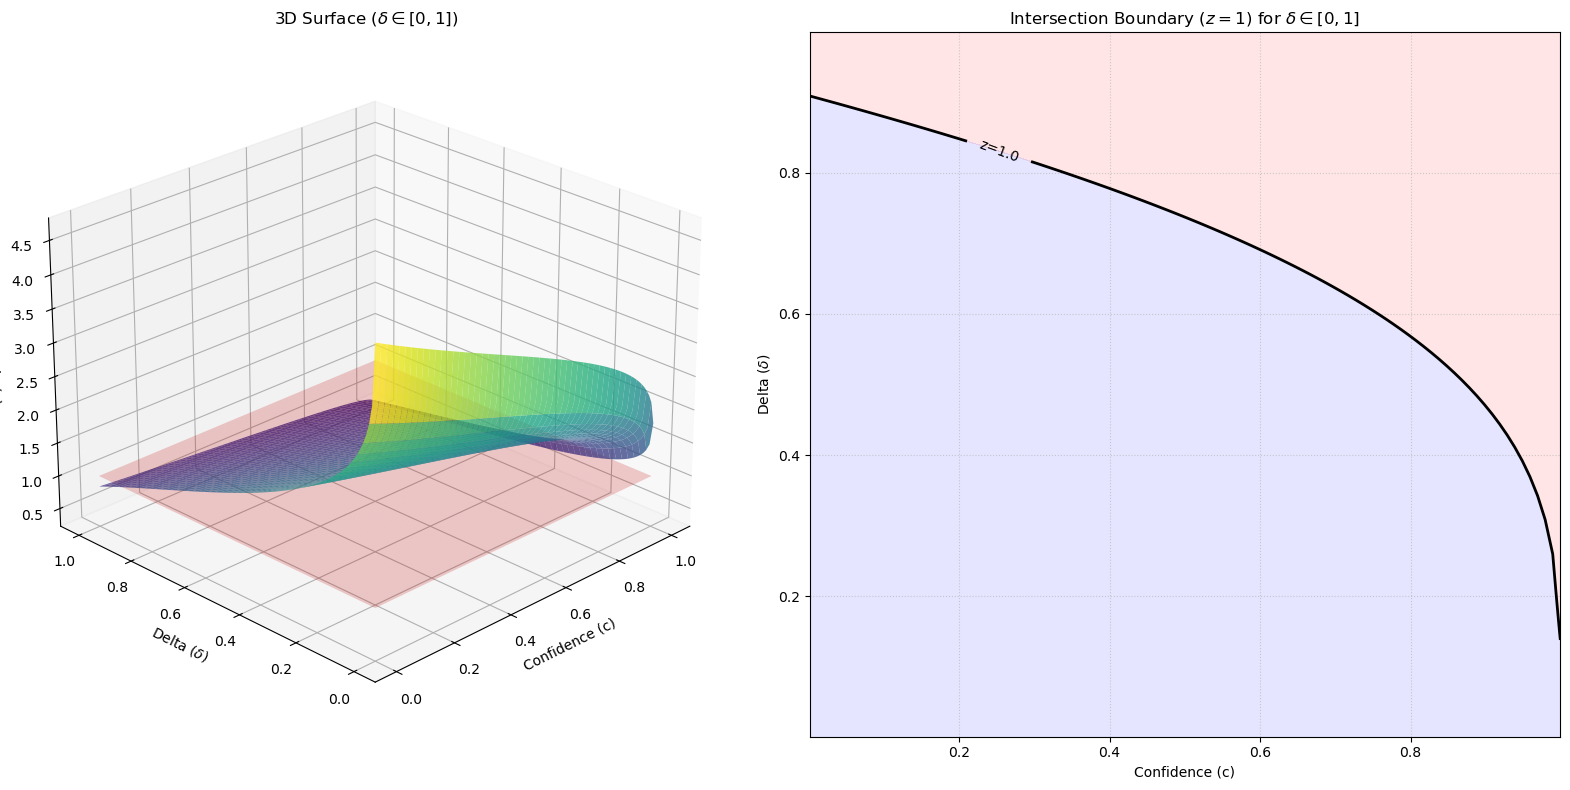

In [8]:
#Now, to analyze and compare the accuracy of the gaussian and laplacian mechanisms in both output cases, we take their ratio.
#The ratio is independent of epsilon as we see, and is only parametrized by confidence c and bad mass upper bound percentage del.
#We see that for most cases in the possible space for c v.s. del (this is basically the square with corners 0,0; 1,0; 1,1; 0,1) the ratio is greater than 1.
#This would mean that the width of the gaussian confidence bounds is greater than the laplacian bounds.
#In other words, laplacian mechanism is more accurate than the gaussian mechanism for most possible cases.
#The left graph sketched the surface of the ratio wrt c and del.
#Right graph shows the intersection of that surface with z = 1 as viewed from the top view. This is to differentiate the different accuracy regions.
#Blue part in the left graph is for z > 1. Red part is for z < 1. This shows which mechanism dominates for the same epsilon.
#Used gemini to produce the graphs accordingly.
from scipy.special import erfinv
from matplotlib import cm

# 1. Define the grid for c (Confidence) and delta
# c goes from 0 to 1, delta now goes from 0 to 1
c = np.linspace(0.001, 0.999, 100)
delta = np.linspace(0.001, 0.999, 100) # Updated range
C, DEL = np.meshgrid(c, delta)

# 2. Calculate Z based on the formula:
# z = [2 * erfinv(c) * sqrt(ln(1.25/delta))] / ln(1/(1-c))
numerator = 2 * erfinv(C) * np.sqrt(np.log(1.25 / DEL))
denominator = np.log(1 / (1 - C))
Z = numerator / denominator

# 3. Setup the visualization
fig = plt.figure(figsize=(16, 8))

# --- Subplot 1: 3D Surface Plot ---
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(C, DEL, Z, cmap=cm.viridis, alpha=0.8, antialiased=True)

# Reference plane at z = 1
ax1.plot_surface(C, DEL, np.ones_like(Z), color='red', alpha=0.2)

# Labeling with 'r' prefix for LaTeX
ax1.set_xlabel('Confidence (c)')
ax1.set_ylabel(r'Delta ($\delta$)')
ax1.set_zlabel('Ratio (z)')
ax1.set_title(r'3D Surface ($\delta \in [0, 1]$)')
ax1.view_init(elev=25, azim=-135)

# --- Subplot 2: 2D Projection (z=1) ---
ax2 = fig.add_subplot(122)

# Contour at z=1
contour = ax2.contour(C, DEL, Z, levels=[1.0], colors='black', linewidths=2)
ax2.clabel(contour, inline=True, fmt="z=1.0", fontsize=10)

# Colored regions: Red where Gaussian is tighter, Blue where Laplace is tighter
ax2.contourf(C, DEL, Z, levels=[0, 1], colors=['red'], alpha=0.1)
ax2.contourf(C, DEL, Z, levels=[1, np.max(Z)], colors=['blue'], alpha=0.1)

ax2.set_xlabel('Confidence (c)')
ax2.set_ylabel(r'Delta ($\delta$)')
ax2.set_title(r'Intersection Boundary ($z=1$) for $\delta \in [0, 1]$')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()